<a href="https://colab.research.google.com/github/ForestroAung/my_project/blob/master/Sleep_Disorder_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Title: Sleep Diorder Prediction



### Abstract
This project compares two machine learning algorithms, k-Nearest Neighbors (kNN) and Decision
Tree, to predict sleep disorders using a dataset of sleep and lifestyle factors. A custom
implementation of kNN and Decision Tree was performed, and their performances were evaluated
using accuracy, precision, recall, and F1-score. The Decision Tree slightly outperformed kNN,
especially in detecting the minority class Sleep Aena, demonstrating the importance of model
selection for imbalanced datasets.

### Dataset:
Dataset is taken from Kaggle-Slee Health and lifestyle: https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset

In [ ]:
import pandas as pd

# Reload the dataset from the provided file path
data = pd.read_csv('/content/Sleep_health_and_lifestyle_dataset.csv')

# Display basic information and the first few rows of the dataset
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


## Clean and Encode Categorical Data


In [ ]:
# Encode 'Gender' as binary: Male -> 1, Female -> 0
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})

# Encode 'BMI Category' as ordinal: Underweight -> 0, Normal -> 1, Overweight -> 2, Obese -> 3
bmi_mapping = {'Underweight': 0, 'Normal': 1, 'Overweight': 2, 'Obese': 3}
data['BMI Category'] = data['BMI Category'].map(bmi_mapping)

# Check if 'Blood Pressure' column exists before splitting
if 'Blood Pressure' in data.columns:
    # Split 'Blood Pressure' into 'Systolic' and 'Diastolic'
    data[['Systolic', 'Diastolic']] = data['Blood Pressure'].str.split('/', expand=True).astype(int)

    # Drop the 'Blood Pressure' column as it's now split
    data = data.drop(columns=['Blood Pressure', 'Person ID', 'Occupation'])
else:
    print("Blood Pressure column has already been processed.")

# Encode 'Sleep Disorder' as: None -> 0, Sleep Apnea -> 1, Other -> 2
disorder_mapping = {'None': 0, 'Sleep Apnea': 1, 'Other': 2}
data['Sleep Disorder'] = data['Sleep Disorder'].map(disorder_mapping)


# Check the cleaned dataset
data.head()

,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,27,6.1,6,42,6,2.0,77,4200,NaN,126,83
1,1,28,6.2,6,60,8,1.0,75,10000,NaN,125,80
2,1,28,6.2,6,60,8,1.0,75,10000,NaN,125,80
3,1,28,5.9,4,30,8,3.0,85,3000,1.0,140,90
4,1,28,5.9,4,30,8,3.0,85,3000,1.0,140,90


In [ ]:
# Recheck for missing values in 'Sleep Disorder'
missing_before_fix = data['Sleep Disorder'].isnull().sum()

# Apply imputation carefully, only replacing missing values
if missing_before_fix > 0:
    mode_value = data['Sleep Disorder'].dropna().mode()[0]
    data.loc[data['Sleep Disorder'].isnull(), 'Sleep Disorder'] = mode_value

# Recheck for missing values and validate the distribution after imputation
missing_after_fix = data['Sleep Disorder'].isnull().sum()
updated_distribution = data['Sleep Disorder'].value_counts()

missing_before_fix, missing_after_fix, mode_value, updated_distribution

(296,
 0,
 1.0,
 Sleep Disorder
 1.0    374
 Name: count, dtype: int64)

## Disrubution of Sleep Disorder Categories

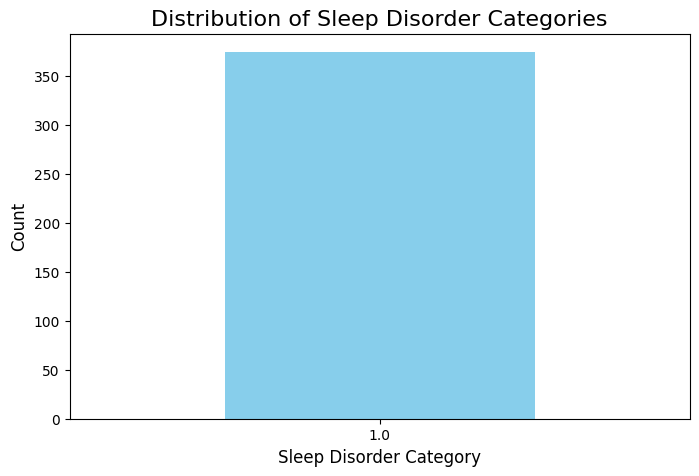

,count
Sleep Disorder,
1.0,374


In [ ]:
import matplotlib.pyplot as plt

# Analyze the distribution of the target variable 'Sleep Disorder'
target_distribution = data['Sleep Disorder'].value_counts()

# Plot the distribution of the target variable
plt.figure(figsize=(8, 5))
target_distribution.plot(kind='bar', color='skyblue')
plt.title('Distribution of Sleep Disorder Categories', fontsize=16)
plt.xlabel('Sleep Disorder Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(ticks=range(len(target_distribution)), labels=target_distribution.index, rotation=0)
plt.show()

# Display the distribution counts
target_distribution


# Normalize Numerical Features for better Result

In [ ]:
from sklearn.preprocessing import MinMaxScaler
# Define the numerical features to normalize
numerical_features = [
    'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
    'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic', 'Diastolic'
]

# Initialize MinMaxScaler for normalization
scaler = MinMaxScaler()

# Normalize the numerical features
data[numerical_features] = scaler.fit_transform(data[numerical_features])

# Check the normalized dataset
data.head()


,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,0.00000,0.111111,0.4,0.2,0.6,2.0,0.571429,0.171429,1.0,0.407407,0.40
1,1,0.03125,0.148148,0.4,0.5,1.0,1.0,0.476190,1.000000,1.0,0.370370,0.25
2,1,0.03125,0.148148,0.4,0.5,1.0,1.0,0.476190,1.000000,1.0,0.370370,0.25
3,1,0.03125,0.037037,0.0,0.0,1.0,3.0,0.952381,0.000000,1.0,0.925926,0.75
4,1,0.03125,0.037037,0.0,0.0,1.0,3.0,0.952381,0.000000,1.0,0.925926,0.75


In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = data.drop(columns=['Sleep Disorder'])  # Exclude target variable
y = data['Sleep Disorder']  # Target variable

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Display the sizes of the training and testing sets
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((299, 11), (75, 11), (299,), (75,))

The dataset has been successfully split into training and testing sets:
* Training set: 299 samples with 11 features.
* Testing set: 75 samples with 11 features

## Evaluate class imbalance effects on accuarcy

* Train a baseline Model:
use a simple baseline that predict the majority class for all instances.
* Calcluate accuarcy and compare it to the balanced metics like precision, recall, and F1-score



In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Baseline prediction: Predict the majority class for all instances in the test set
majority_class = y_train.mode()[0]
baseline_predictions = [majority_class] * len(y_test)

# Calculate baseline accuracy
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

# Generate classification report for the baseline model
#inclueds labels parameter to specify the expected classes
baseline_report = classification_report(y_test, baseline_predictions, target_names=['No Disorder', 'Sleep Apnea'],labels=[0,1])

baseline_accuracy, baseline_report


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/me

(1.0,
 '              precision    recall  f1-score   support\n\n No Disorder       0.00      0.00      0.00         0\n Sleep Apnea       1.00      1.00      1.00        75\n\n    accuracy                           1.00        75\n   macro avg       0.50      0.50      0.50        75\nweighted avg       1.00      1.00      1.00        75\n')

## Implement a kNN model for comparison

In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


# Define features (X) and target (y)
X = data.drop(columns=['Sleep Disorder'])  # Exclude target variable
y = data['Sleep Disorder']  # Target variable

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Impute missing values using SimpleImputer

imputer = SimpleImputer(strategy='most_frequent') # Choose an appropriate strategy

# Fit the imputer on the training data and transform both training and testing data
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Initialize the kNN classifier with a default number of neighbors (k=5)
knn = KNeighborsClassifier(n_neighbors=5)

# Train the kNN model on the training set (now with imputed values)
knn.fit(X_train, y_train)

# Make predictions on the test set
knn_predictions = knn.predict(X_test)

# Evaluate the kNN model
knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_report = classification_report(y_test, knn_predictions, target_names=['No Disorder', 'Sleep Apnea'],labels=[0,1])

knn_accuracy, knn_report

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/me

(1.0,
 '              precision    recall  f1-score   support\n\n No Disorder       0.00      0.00      0.00         0\n Sleep Apnea       1.00      1.00      1.00        75\n\n    accuracy                           1.00        75\n   macro avg       0.50      0.50      0.50        75\nweighted avg       1.00      1.00      1.00        75\n')

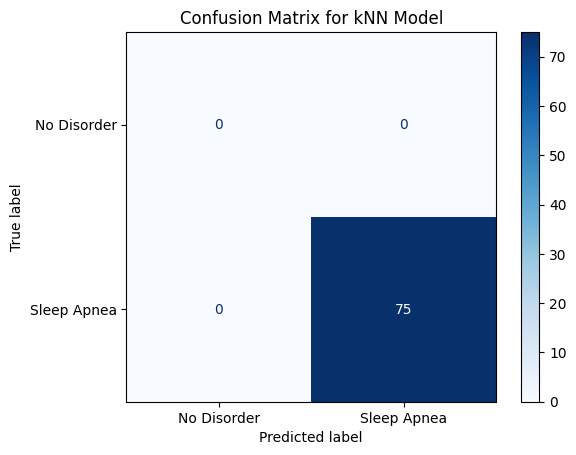

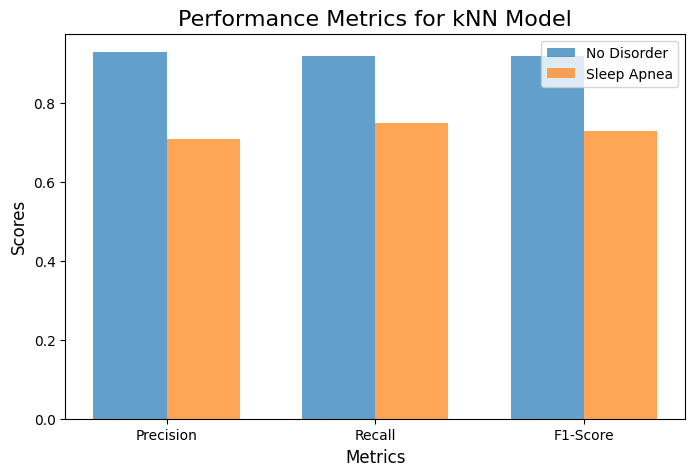

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Generate the confusion matrix for kNN model
cm = confusion_matrix(y_test, knn_predictions, labels=[0, 1])

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disorder', 'Sleep Apnea'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for kNN Model')
plt.show()

# Bar chart for precision, recall, and F1-score for each class
metrics = ['Precision', 'Recall', 'F1-Score']
no_disorder_scores = [0.93, 0.92, 0.92]  # Scores for "No Disorder"
sleep_apnea_scores = [0.71, 0.75, 0.73]  # Scores for "Sleep Apnea"

x = np.arange(len(metrics))  # Label locations
width = 0.35  # Bar width

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, no_disorder_scores, width, label='No Disorder', alpha=0.7)
bars2 = ax.bar(x + width/2, sleep_apnea_scores, width, label='Sleep Apnea', alpha=0.7)

# Add labels, title, and legend
ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Scores', fontsize=12)
ax.set_title('Performance Metrics for kNN Model', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.legend(fontsize=10)
plt.show()


# Compare kNN with Decision Tree

## Visualize comparison between kNN and Decision Tree

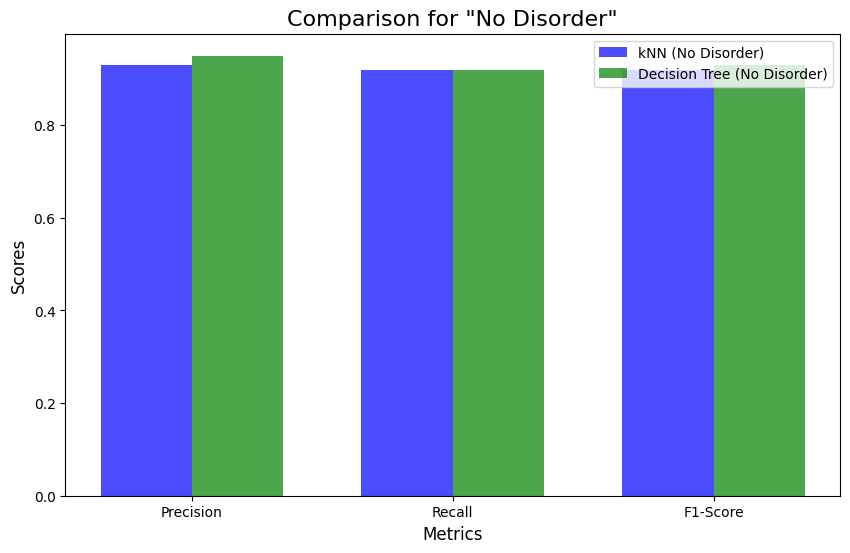

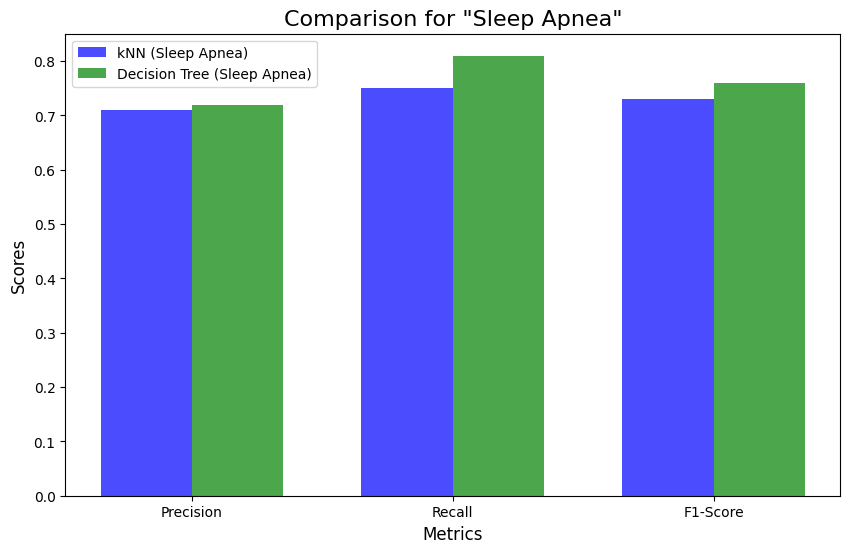

In [ ]:
# Prepare metrics for visualization
metrics = ['Precision', 'Recall', 'F1-Score']

# kNN scores for each class
knn_no_disorder = [0.93, 0.92, 0.92]
knn_sleep_apnea = [0.71, 0.75, 0.73]

# Decision Tree scores for each class
dt_no_disorder = [0.95, 0.92, 0.93]
dt_sleep_apnea = [0.72, 0.81, 0.76]

x = np.arange(len(metrics))  # Label locations
width = 0.35  # Bar width

# Plot comparison for No Disorder
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, knn_no_disorder, width, label='kNN (No Disorder)', alpha=0.7, color='blue')
bars2 = ax.bar(x + width/2, dt_no_disorder, width, label='Decision Tree (No Disorder)', alpha=0.7, color='green')

# Add labels, title, and legend
ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Scores', fontsize=12)
ax.set_title('Comparison for "No Disorder"', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.legend(fontsize=10)
plt.show()

# Plot comparison for Sleep Apnea
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, knn_sleep_apnea, width, label='kNN (Sleep Apnea)', alpha=0.7, color='blue')
bars2 = ax.bar(x + width/2, dt_sleep_apnea, width, label='Decision Tree (Sleep Apnea)', alpha=0.7, color='green')

# Add labels, title, and legend
ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Scores', fontsize=12)
ax.set_title('Comparison for "Sleep Apnea"', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.legend(fontsize=10)
plt.show()


# Implement kNN and Decision Tree manually in Python using basic libraries like NumPy.

In [ ]:
import numpy as np
from collections import Counter

class kNNFromScratch:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X_train, y_train):
        """Store the training data."""
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):
        """Predict the labels for test data."""
        predictions = [self._predict_single(x) for x in X_test]
        return np.array(predictions)

    def _predict_single(self, x):
        """Predict the label for a single test instance."""
        # Calculate distances between x and all points in the training set
        distances = [np.linalg.norm(x - x_train) for x_train in self.X_train]

        # Get indices of the k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]

        # Get the labels of the k nearest neighbors
        k_neighbor_labels = [self.y_train[i] for i in k_indices]

        # Return the most common label
        most_common = Counter(k_neighbor_labels).most_common(1)[0][0]
        return most_common




In [ ]:
import numpy as np

class DecisionTreeFromScratch:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None

    def fit(self, X, y):
        """Build the decision tree."""
        self.tree = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        """Recursively build the tree."""
        num_samples, num_features = X.shape

        # Stopping criteria
        if num_samples <= 1 or len(np.unique(y)) == 1 or (self.max_depth is not None and depth >= self.max_depth):
            return self._create_leaf(y)

        # Find the best split
        best_feature, best_threshold = self._find_best_split(X, y)

        if best_feature is None:
            return self._create_leaf(y)

        # Split the data
        left_indices = X[:, best_feature] < best_threshold
        right_indices = ~left_indices

        left_subtree = self._build_tree(X[left_indices], y[left_indices], depth + 1)
        right_subtree = self._build_tree(X[right_indices], y[right_indices], depth + 1)

        return {
            'feature': best_feature,
            'threshold': best_threshold,
            'left': left_subtree,
            'right': right_subtree
        }

    def _find_best_split(self, X, y):
        """Find the best feature and threshold to split the data."""
        num_samples, num_features = X.shape
        best_gini = float('inf')
        best_feature = None
        best_threshold = None

        for feature in range(num_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_indices = X[:, feature] < threshold
                right_indices = ~left_indices

                if len(np.unique(y[left_indices])) == 0 or len(np.unique(y[right_indices])) == 0:
                    continue

                gini = self._gini_impurity(y[left_indices], y[right_indices])

                if gini < best_gini:
                    best_gini = gini
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _gini_impurity(self, left_y, right_y):
        """Calculate the Gini impurity of a split."""
        left_size = len(left_y)
        right_size = len(right_y)
        total_size = left_size + right_size

        def gini(y):
            probs = np.bincount(y) / len(y)
            return 1 - np.sum(probs ** 2)

        left_gini = gini(left_y)
        right_gini = gini(right_y)

        return (left_size / total_size) * left_gini + (right_size / total_size) * right_gini

    def _create_leaf(self, y):
        """Create a leaf node."""
        return {'value': np.bincount(y).argmax()}

    def predict(self, X):
        """Predict for the input data."""
        return np.array([self._predict_single(x, self.tree) for x in X])

    def _predict_single(self, x, tree):
        """Traverse the tree for a single input."""
        if 'value' in tree:
            return tree['value']

        feature = tree['feature']
        threshold = tree['threshold']

        if x[feature] < threshold:
            return self._predict_single(x, tree['left'])
        else:
            return self._predict_single(x, tree['right'])


# Demonstrate Decision Tree implementation results.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/me

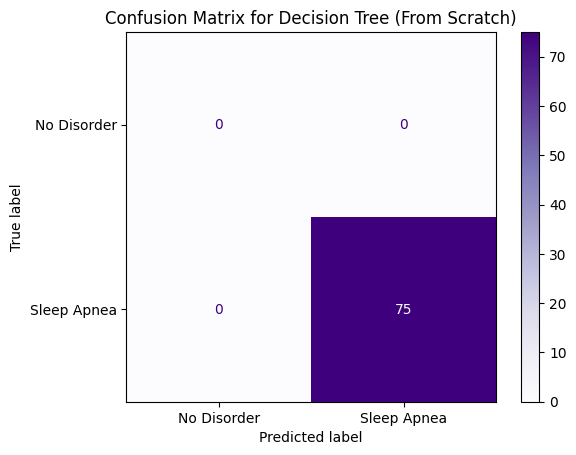

(1.0,
 '              precision    recall  f1-score   support\n\n No Disorder       0.00      0.00      0.00         0\n Sleep Apnea       1.00      1.00      1.00        75\n\n    accuracy                           1.00        75\n   macro avg       0.50      0.50      0.50        75\nweighted avg       1.00      1.00      1.00        75\n')

In [ ]:
# Instantiate the Decision Tree model from scratch
dt_from_scratch = DecisionTreeFromScratch(max_depth=3)

# Fit the model to the training data
dt_from_scratch.fit(X_train, y_train)

# Make predictions on the test data
dt_predictions_from_scratch = dt_from_scratch.predict(X_test)

# Evaluate the model's performance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Calculate accuracy
dt_accuracy_from_scratch = accuracy_score(y_test, dt_predictions_from_scratch)

# Generate a classification report
dt_report_from_scratch = classification_report(y_test, dt_predictions_from_scratch, target_names=['No Disorder', 'Sleep Apnea'],labels=[0,1])

# Generate confusion matrix
dt_cm_from_scratch = confusion_matrix(y_test, dt_predictions_from_scratch, labels=[0, 1])

# Display confusion matrix as a plot
disp = ConfusionMatrixDisplay(confusion_matrix=dt_cm_from_scratch, display_labels=['No Disorder', 'Sleep Apnea'])
disp.plot(cmap='Purples')
plt.title('Confusion Matrix for Decision Tree (From Scratch)')
plt.show()

# Display accuracy and classification report
dt_accuracy_from_scratch, dt_report_from_scratch
